#Business Understanding
###Evaluation of Solar Energy Feasibility

The purpose of evaluating solar energy feasibility is to determine whether installing a solar energy system (such as solar panels) at a specific location is viable from technical, economic, and environmental perspectives. This evaluation helps decision-makers (individuals, companies, or governments) plan solar energy investments more effectively.

Since the dataset does not yet have labels, a clustering approach is more appropriate to automatically generate feasibility categories.

The clustering results can then be interpreted manually as labels, for example:

1.   Cluster 1 → High viability score → "Highly Feasible"
2.   Cluster 2 → Medium score → "Feasible"
3.   Cluster 3 → Low score → "Less Feasible"


# Dataset
 (https://www.kaggle.com/datasets/shaistashahid/urban-solar-roi-and-sustainability)

# About Dataset.
 Comparative Analysis of Solar Feasibility, Market Economics & Carbon Reduction
Solar Energy Potential & Economics Dataset
This dataset provides key metrics for evaluating solar energy feasibility across different cities worldwide.
It includes geographic information, solar radiation characteristics, installation statistics, cost estimates,
economic returns, and environmental impact to support solar energy planning, policy research, and market analysis.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import scipy as sp

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for path, dirs, files in os.walk('/kaggle/input/urban-solar-roi-and-sustainability'):
    for file in files:
        print(os.path.join(path, file))

#Kaggle

In [2]:
df = pd.read_csv("solar_energy_worldwide.csv")


# Data Understanding
###Eksploratory data analysis

Number of Data and Data Dimensions

In [3]:
df.shape

(48, 17)

In [4]:
df.size

816

In [5]:
df.head()

,City,Country,Latitude,Longitude,Annual_Sunlight_Hours,Daily_Peak_Sun_Hours,GHI_kWh_per_m2,Electricity_Price_USD_per_kWh,Solar_Installations_Count,Avg_System_Cost_USD,Avg_Annual_Production_kWh,Estimated_Annual_Savings_USD,Payback_Period_Years,ROI_Percentage,CO2_Reduction_Tons_per_Year,Solar_Viability_Score,Region
0,New York,United States,40.71,-74.01,2500,6.8,4.5,0.15,142000,15000,11250,1687.5,8.9,11.2,4.50,56,North America
1,Los Angeles,United States,34.05,-118.24,3200,8.8,5.8,0.15,142000,15000,14400,2160.0,6.9,14.5,5.76,67,North America
2,Miami,United States,25.76,-80.19,3000,8.2,5.3,0.15,142000,15000,13500,2025.0,7.4,13.5,5.40,63,North America
3,Phoenix,United States,33.45,-112.07,3800,10.4,6.5,0.15,142000,15000,17100,2565.0,5.8,17.2,6.84,73,North America
4,Chicago,United States,41.88,-87.63,2300,6.3,4.2,0.15,142000,15000,10350,1552.5,9.7,10.3,4.14,53,North America


# Type Variable

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   City                           48 non-null     object 
 1   Country                        48 non-null     object 
 2   Latitude                       48 non-null     float64
 3   Longitude                      48 non-null     float64
 4   Annual_Sunlight_Hours          48 non-null     int64  
 5   Daily_Peak_Sun_Hours           48 non-null     float64
 6   GHI_kWh_per_m2                 48 non-null     float64
 7   Electricity_Price_USD_per_kWh  48 non-null     float64
 8   Solar_Installations_Count      48 non-null     int64  
 9   Avg_System_Cost_USD            48 non-null     int64  
 10  Avg_Annual_Production_kWh      48 non-null     int64  
 11  Estimated_Annual_Savings_USD   48 non-null     float64
 12  Payback_Period_Years           48 non-null     float

In [7]:
df.sum()

,0
City,New YorkLos AngelesMiamiPhoenixChicagoBerlinMu...
Country,United StatesUnited StatesUnited StatesUnited ...
Latitude,1133.25
Longitude,845.34
Annual_Sunlight_Hours,115750
Daily_Peak_Sun_Hours,316.9
GHI_kWh_per_m2,217.5
Electricity_Price_USD_per_kWh,7.2
Solar_Installations_Count,2328540
Avg_System_Cost_USD,720000


In [8]:
df.isnull().sum()

,0
City,0
Country,0
Latitude,0
Longitude,0
Annual_Sunlight_Hours,0
Daily_Peak_Sun_Hours,0
GHI_kWh_per_m2,0
Electricity_Price_USD_per_kWh,0
Solar_Installations_Count,0
Avg_System_Cost_USD,0


#Statistical Information of the Data

In [9]:
df.describe()

,Latitude,Longitude,Annual_Sunlight_Hours,Daily_Peak_Sun_Hours,GHI_kWh_per_m2,Electricity_Price_USD_per_kWh,Solar_Installations_Count,Avg_System_Cost_USD,Avg_Annual_Production_kWh,Estimated_Annual_Savings_USD,Payback_Period_Years,ROI_Percentage,CO2_Reduction_Tons_per_Year,Solar_Viability_Score
count,48.000000,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.0,48.00000,48.000000,48.000000,48.000000,48.000000,48.00000
mean,23.609375,17.611250,2411.458333,6.602083,4.531250,1.500000e-01,48511.250000,15000.0,10851.56250,1627.734375,9.781250,10.862500,4.340625,54.50000
std,30.181205,78.169395,582.752053,1.594470,1.000459,1.402465e-16,126091.425183,0.0,2622.38424,393.357636,2.488412,2.647731,1.048954,9.81965
min,-37.810000,-123.120000,1450.000000,4.000000,2.800000,1.500000e-01,150.000000,15000.0,6525.00000,978.750000,5.800000,6.500000,2.610000,36.00000
25%,10.512500,-44.035000,1887.500000,5.175000,3.800000,1.500000e-01,1750.000000,15000.0,8493.75000,1274.062500,7.850000,8.450000,3.397500,47.75000
50%,34.370000,12.040000,2450.000000,6.700000,4.650000,1.500000e-01,4800.000000,15000.0,11025.00000,1653.750000,9.100000,11.000000,4.410000,56.50000
75%,45.535000,77.305000,2825.000000,7.750000,5.300000,1.500000e-01,13625.000000,15000.0,12712.50000,1906.875000,11.775000,12.775000,5.085000,62.25000
max,59.910000,153.030000,3800.000000,10.400000,6.500000,1.500000e-01,609000.000000,15000.0,17100.00000,2565.000000,15.300000,17.200000,6.840000,73.00000


In [10]:
df.duplicated().sum()

np.int64(0)

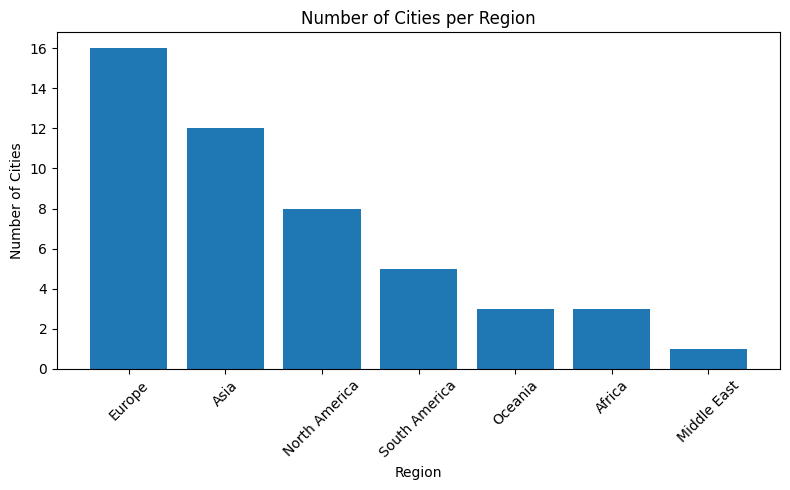

In [11]:
# Bar Chart: Number of Cities per Region
region_counts = df['Region'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(region_counts.index, region_counts.values)

plt.title('Number of Cities per Region')
plt.xlabel('Region')
plt.ylabel('Number of Cities')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

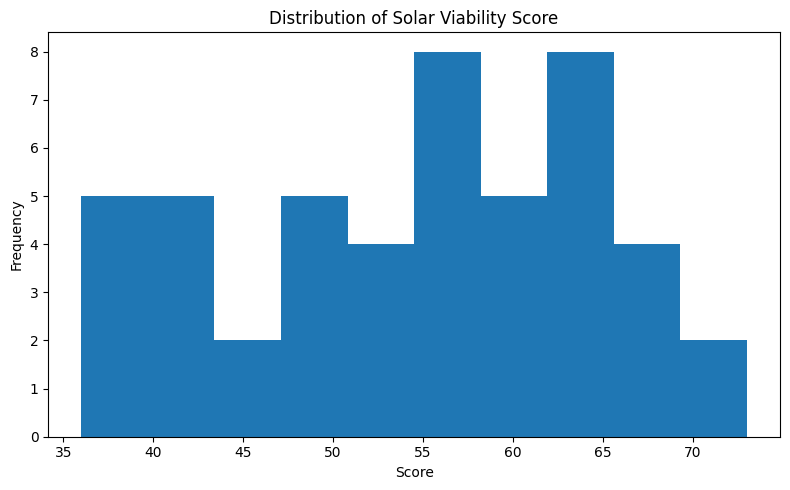

In [12]:
# Histogram: Solar Viability Score
plt.figure(figsize=(8,5))

plt.hist(df['Solar_Viability_Score'])

plt.title('Distribution of Solar Viability Score')
plt.xlabel('Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

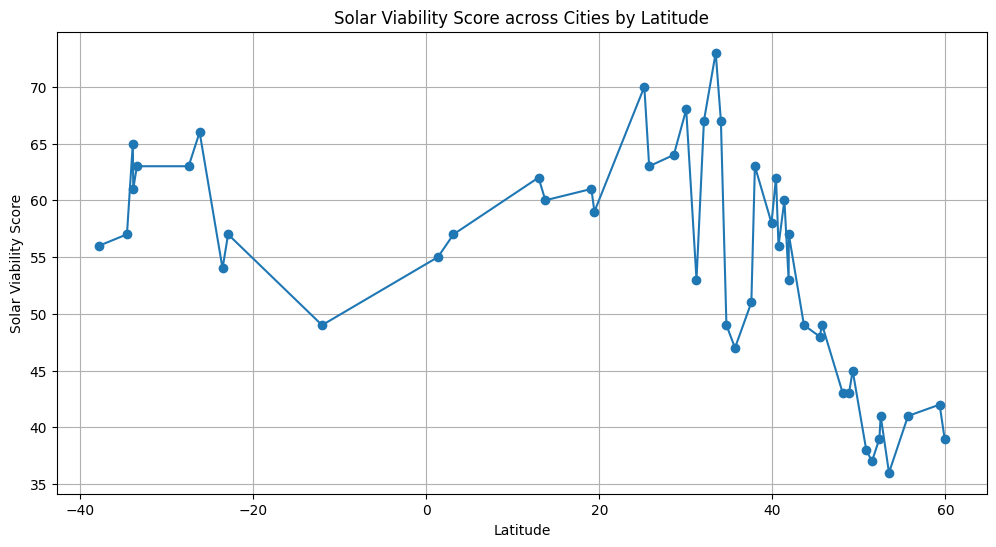

In [13]:
# Sort DataFrame by Latitude for a clearer trend visualization
df_sorted_by_latitude = df.sort_values(by='Latitude').reset_index(drop=True)

# Line Chart: Latitude vs Solar Viability Score
plt.figure(figsize=(12, 6))
plt.plot(df_sorted_by_latitude['Latitude'], df_sorted_by_latitude['Solar_Viability_Score'], marker='o', linestyle='-')
plt.title('Solar Viability Score across Cities by Latitude')
plt.xlabel('Latitude')
plt.ylabel('Solar Viability Score')
plt.grid(True)
plt.show()

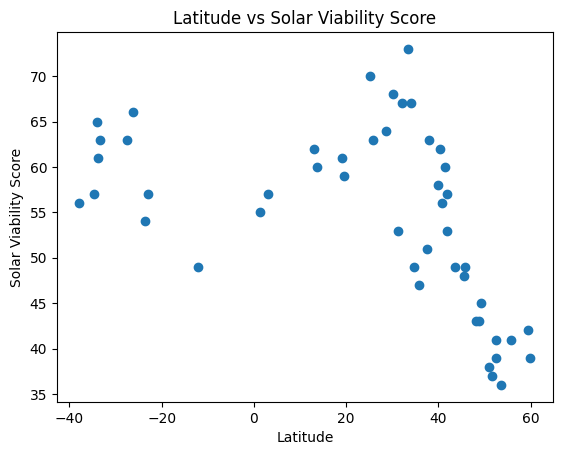

In [14]:
# Scatter Plot: Latitude vs Solar Viability Score
plt.scatter(df['Latitude'], df['Solar_Viability_Score'])
plt.title('Latitude vs Solar Viability Score')
plt.xlabel('Latitude')
plt.ylabel('Solar Viability Score')
plt.show()

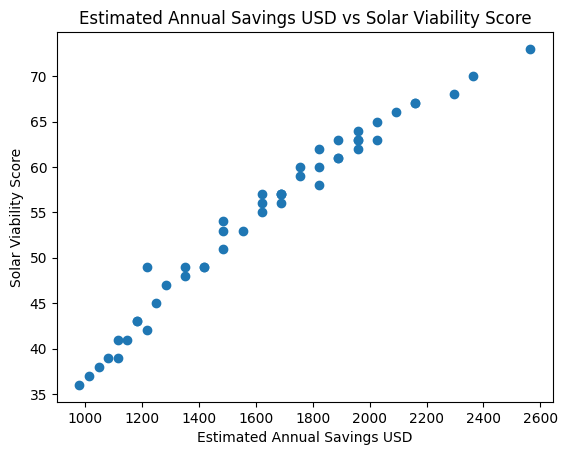

In [15]:
# Scatter Plot: Latitude vs Solar Viability Score
plt.scatter(df['Estimated_Annual_Savings_USD'], df['Solar_Viability_Score'])
plt.title('Estimated Annual Savings USD vs Solar Viability Score')
plt.xlabel('Estimated Annual Savings USD')
plt.ylabel('Solar Viability Score')
plt.show()

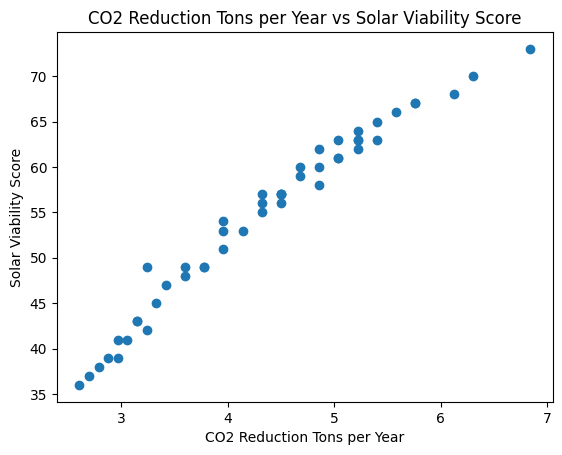

In [16]:
# Scatter Plot: Latitude vs Solar Viability Score
plt.scatter(df['CO2_Reduction_Tons_per_Year'], df['Solar_Viability_Score'])
plt.title('CO2 Reduction Tons per Year vs Solar Viability Score')
plt.xlabel('CO2 Reduction Tons per Year')
plt.ylabel('Solar Viability Score')
plt.show()

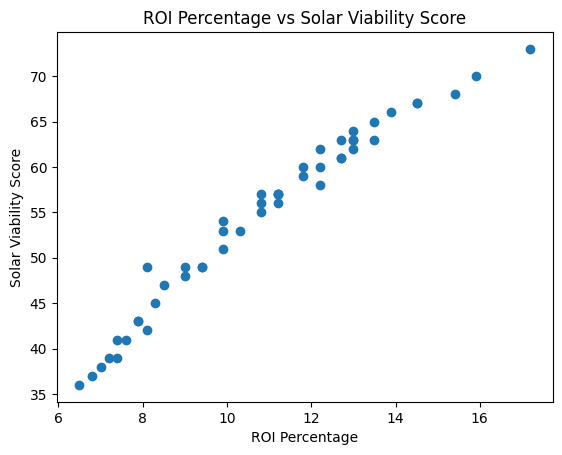

In [17]:
# Scatter Plot: Latitude vs Solar Viability Score
plt.scatter(df['ROI_Percentage'], df['Solar_Viability_Score'])
plt.title('ROI Percentage vs Solar Viability Score')
plt.xlabel('ROI Percentage')
plt.ylabel('Solar Viability Score')
plt.show()

Based on the visualization of each feature, not all features show a linear relationship with the Viability Score. Therefore, a clustering model is more appropriate to analyze the feasibility potential of solar energy from multiple perspectives.

#Preprocessing Data

#Check for Duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.duplicated(['Solar_Viability_Score', 'Region']).sum()

np.int64(4)

In [20]:
df.duplicated(['Solar_Viability_Score', 'Estimated_Annual_Savings_USD']).sum()

np.int64(7)

There are some duplicate values across columns, such as between Solar Viability Score and Region or Estimated Annual Saving. However, these data points will not be removed due to the small size of the dataset and to ensure the clustering process remains as natural as possible.

#Missing Value

In [21]:
df.isna().sum()

,0
City,0
Country,0
Latitude,0
Longitude,0
Annual_Sunlight_Hours,0
Daily_Peak_Sun_Hours,0
GHI_kWh_per_m2,0
Electricity_Price_USD_per_kWh,0
Solar_Installations_Count,0
Avg_System_Cost_USD,0


#Outlier Handling

In [22]:
df.describe()

,Latitude,Longitude,Annual_Sunlight_Hours,Daily_Peak_Sun_Hours,GHI_kWh_per_m2,Electricity_Price_USD_per_kWh,Solar_Installations_Count,Avg_System_Cost_USD,Avg_Annual_Production_kWh,Estimated_Annual_Savings_USD,Payback_Period_Years,ROI_Percentage,CO2_Reduction_Tons_per_Year,Solar_Viability_Score
count,48.000000,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.0,48.00000,48.000000,48.000000,48.000000,48.000000,48.00000
mean,23.609375,17.611250,2411.458333,6.602083,4.531250,1.500000e-01,48511.250000,15000.0,10851.56250,1627.734375,9.781250,10.862500,4.340625,54.50000
std,30.181205,78.169395,582.752053,1.594470,1.000459,1.402465e-16,126091.425183,0.0,2622.38424,393.357636,2.488412,2.647731,1.048954,9.81965
min,-37.810000,-123.120000,1450.000000,4.000000,2.800000,1.500000e-01,150.000000,15000.0,6525.00000,978.750000,5.800000,6.500000,2.610000,36.00000
25%,10.512500,-44.035000,1887.500000,5.175000,3.800000,1.500000e-01,1750.000000,15000.0,8493.75000,1274.062500,7.850000,8.450000,3.397500,47.75000
50%,34.370000,12.040000,2450.000000,6.700000,4.650000,1.500000e-01,4800.000000,15000.0,11025.00000,1653.750000,9.100000,11.000000,4.410000,56.50000
75%,45.535000,77.305000,2825.000000,7.750000,5.300000,1.500000e-01,13625.000000,15000.0,12712.50000,1906.875000,11.775000,12.775000,5.085000,62.25000
max,59.910000,153.030000,3800.000000,10.400000,6.500000,1.500000e-01,609000.000000,15000.0,17100.00000,2565.000000,15.300000,17.200000,6.840000,73.00000


Solar Installation Count and Longitude show large differences between the mean, median, and maximum values, indicating that the data distribution is skewed (non-normal). Features with wide value ranges like this tend to contain outliers and non-normal distributions.The next step is to visualize the data and handle outliers, followed by applying a log transformation.

In [23]:
!pip install seaborn


<Axes: ylabel='Solar_Installations_Count'>

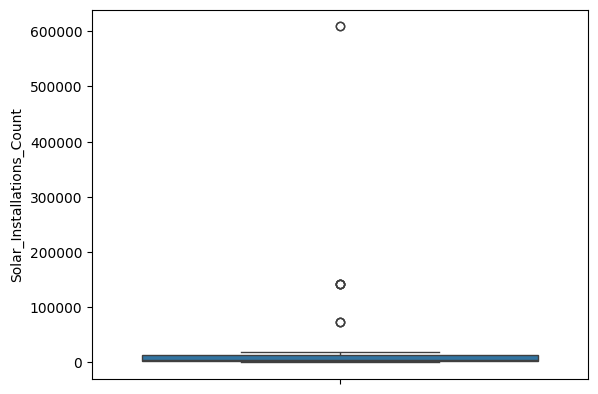

In [24]:
import seaborn as sns
sns.boxplot(df['Solar_Installations_Count'])

<Axes: ylabel='Longitude'>

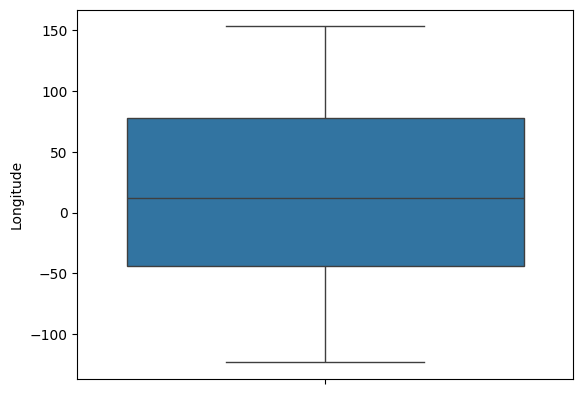

In [25]:
import seaborn as sns

sns.boxplot(df['Longitude'])

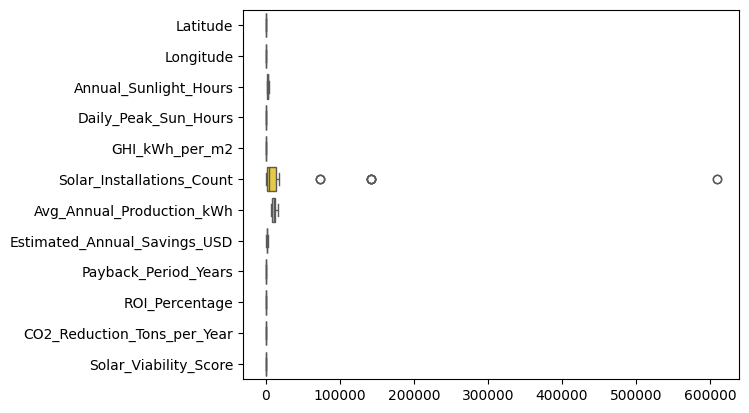

In [26]:
#Check Outliers Using Boxplot

df_1 = ['Latitude', 'Longitude', 'Annual_Sunlight_Hours', 'Daily_Peak_Sun_Hours',
    'GHI_kWh_per_m2', 'Solar_Installations_Count', 'Avg_Annual_Production_kWh',
    'Estimated_Annual_Savings_USD', 'Payback_Period_Years', 'ROI_Percentage',
    'CO2_Reduction_Tons_per_Year', 'Solar_Viability_Score']
ax = sns.boxplot(data=df[df_1], orient="h", palette="Set2")

From the visualization, it can be observed that Solar Installation Count contains outliers. Therefore, this feature needs to be reviewed to gain insights into what might be causing these extreme values. There may be other factors influencing why the Solar Installation Count shows outliers.
Cities such as Shanghai, Beijing, and cities in the US have values significantly higher than the average, which likely contributes to these outliers.

Outlier handling is important for improving the performance of Machine Learning models. However, in clustering models, handling outliers does not always have a significant impact on the clustering results.

In [27]:
def fix_outliers(df, Solar_Installations_Count):
    # Calculate Q1 (first quartile) and Q3 (third quartile)
    Q1 = df[Solar_Installations_Count].quantile(0.25)
    Q3 = df[Solar_Installations_Count].quantile(0.75)
    IQR = Q3 - Q1

    # Determine lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping: Replace outliers with the nearest boundary
    df[Solar_Installations_Count] = np.where(df[Solar_Installations_Count] < lower_bound, lower_bound, df[Solar_Installations_Count])
    df[Solar_Installations_Count] = np.where(df[Solar_Installations_Count] > upper_bound, upper_bound, df[Solar_Installations_Count])

    return df

# Call the function for the 'Solar_Installations_Count' column
df_fixed = fix_outliers(df, 'Solar_Installations_Count')

# Display results before and after
print("Data before fixing:")
print(df)
print("\nData after fixing:")
print(df_fixed)

Data before fixing:
              City         Country  Latitude  Longitude  \
0         New York   United States     40.71     -74.01   
1      Los Angeles   United States     34.05    -118.24   
2            Miami   United States     25.76     -80.19   
3          Phoenix   United States     33.45    -112.07   
4          Chicago   United States     41.88     -87.63   
5           Berlin         Germany     52.52      13.40   
6           Munich         Germany     48.14      11.58   
7           London  United Kingdom     51.51      -0.13   
8       Manchester  United Kingdom     53.48      -2.24   
9            Paris          France     48.86       2.35   
10            Lyon          France     45.76       4.84   
11            Rome           Italy     41.90      12.50   
12           Milan           Italy     45.46       9.19   
13          Madrid           Spain     40.42      -3.70   
14       Barcelona           Spain     41.39       2.16   
15         Toronto          Canada  

In [28]:
# Identify outliers by defining a function
num_features = ['Latitude', 'Longitude', 'Annual_Sunlight_Hours', 'Daily_Peak_Sun_Hours',
    'GHI_kWh_per_m2', 'Solar_Installations_Count', 'Avg_Annual_Production_kWh',
    'Estimated_Annual_Savings_USD', 'Payback_Period_Years', 'ROI_Percentage',
    'CO2_Reduction_Tons_per_Year', 'Solar_Viability_Score']

def detect_outliers(data_out, drop=False):
    for each_feature in data_out.columns:
        feature_data = data_out[each_feature]
        Q1 = np.percentile(feature_data, 25.)
        Q3 = np.percentile(feature_data, 75.)
        IQR = Q3 - Q1
        outlier_step = IQR * 1.5

        outliers = feature_data[
            ~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))
        ].index.tolist()

        if not drop:
            print('For the feature {}, Number of Outliers is {}'.format(each_feature, len(outliers)))

        if drop:
            data_out.drop(outliers, inplace=True, errors='ignore')
            print('Outliers from {} feature removed'.format(each_feature))

# Display outlier data
detect_outliers(df[num_features])

For the feature Latitude, Number of Outliers is 0
For the feature Longitude, Number of Outliers is 0
For the feature Annual_Sunlight_Hours, Number of Outliers is 0
For the feature Daily_Peak_Sun_Hours, Number of Outliers is 0
For the feature GHI_kWh_per_m2, Number of Outliers is 0
For the feature Solar_Installations_Count, Number of Outliers is 0
For the feature Avg_Annual_Production_kWh, Number of Outliers is 0
For the feature Estimated_Annual_Savings_USD, Number of Outliers is 0
For the feature Payback_Period_Years, Number of Outliers is 0
For the feature ROI_Percentage, Number of Outliers is 0
For the feature CO2_Reduction_Tons_per_Year, Number of Outliers is 0
For the feature Solar_Viability_Score, Number of Outliers is 0


#Log Transform

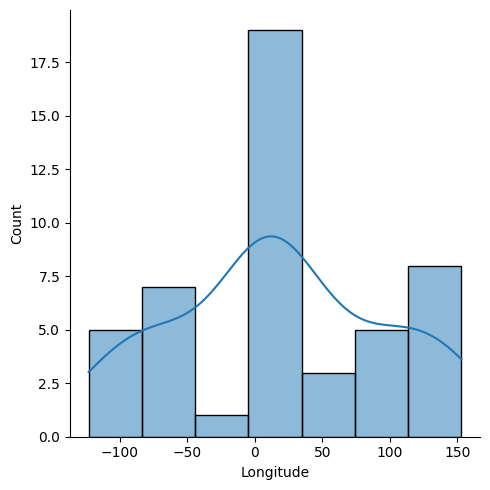

In [29]:
sns.displot(df_fixed['Longitude'], kind='hist', kde=True)

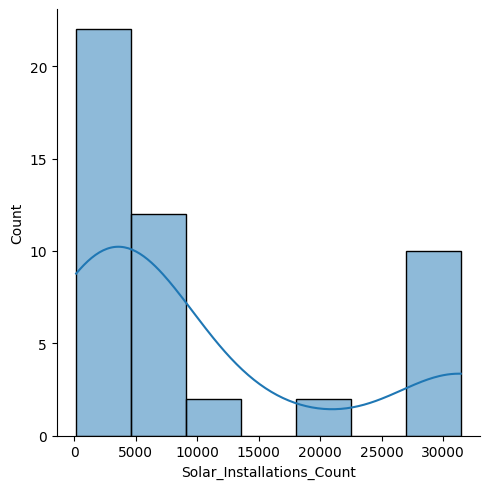

In [30]:
sns.displot(df_fixed['Solar_Installations_Count'], kind='hist', kde=True)

In [31]:
import numpy as np

df_fixed['Solar_Installations_Count'] = np.log(df_fixed['Solar_Installations_Count'])

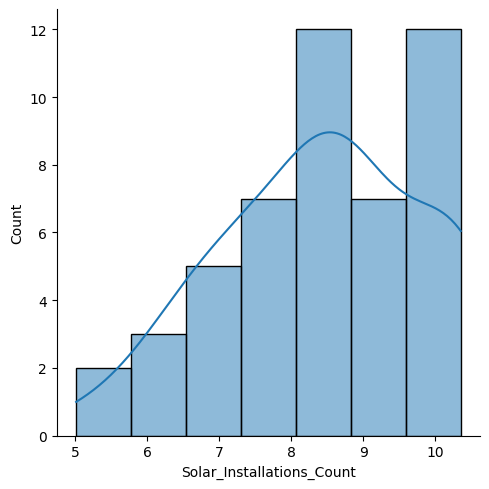

In [32]:
sns.displot(df_fixed['Solar_Installations_Count'], kind='hist', kde=True)

From the visualization above, since Solar Installation Count is a positively skewed feature, it needs to be log-transformed to reduce the range of values and make the distribution closer to normal.

In [33]:
# Preprocessing: Select relevant numerical features
numerical_cols = [
    'Latitude', 'Longitude', 'Annual_Sunlight_Hours', 'Daily_Peak_Sun_Hours',
    'GHI_kWh_per_m2', 'Solar_Installations_Count', 'Avg_Annual_Production_kWh',
    'Estimated_Annual_Savings_USD', 'Payback_Period_Years', 'ROI_Percentage',
    'CO2_Reduction_Tons_per_Year', 'Solar_Viability_Score'
]

X = df_fixed[numerical_cols]

In [34]:
# Check and handle missing values (if any)
if X.isnull().any().any():
    X = X.fillna(X.mean())  # Impute using mean as an example

#Scaling

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dat_scale = scaler.fit_transform(X)
print(dat_scale)

[[0.80352026 0.17783813 0.44680851 0.4375     0.45945946 1.
  0.44680851 0.44680851 0.32631579 0.43925234 0.44680851 0.54054054]
 [0.73536635 0.01767156 0.74468085 0.75       0.81081081 1.
  0.74468085 0.74468085 0.11578947 0.74766355 0.74468085 0.83783784]
 [0.65053213 0.15545899 0.65957447 0.65625    0.67567568 1.
  0.65957447 0.65957447 0.16842105 0.65420561 0.65957447 0.72972973]
 [0.72922636 0.04001448 1.         1.         1.         1.
  1.         1.         0.         1.         1.         1.        ]
 [0.81549325 0.12851711 0.36170213 0.359375   0.37837838 1.
  0.36170213 0.36170213 0.41052632 0.35514019 0.36170213 0.45945946]
 [0.92437577 0.494369   0.08510638 0.078125   0.10810811 0.900801
  0.08510638 0.08510638 0.81052632 0.08411215 0.08510638 0.13513514]
 [0.87955383 0.48777838 0.12765957 0.125      0.16216216 0.900801
  0.12765957 0.12765957 0.72631579 0.13084112 0.12765957 0.18918919]
 [0.91404011 0.44537389 0.0212766  0.015625   0.02702703 0.70511441
  0.0212766  0.02

In [36]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 5.72594407e-01 -1.18448932e+00  1.53544962e-01  1.25440445e-01
  -3.15662185e-02  1.34950106e+00  1.53544962e-01  1.53544962e-01
  -3.57889154e-01  1.28816540e-01  1.53544962e-01  1.54371430e-01]
 [ 3.49592104e-01 -1.75629949e+00  1.36745336e+00  1.39304915e+00
   1.28158847e+00  1.34950106e+00  1.36745336e+00  1.36745336e+00
  -1.17011986e+00  1.38835604e+00  1.36745336e+00  1.28642858e+00]
 [ 7.20111602e-02 -1.26438502e+00  1.02062239e+00  1.01276654e+00
   7.76528976e-01  1.34950106e+00  1.02062239e+00  1.02062239e+00
  -9.67062183e-01  1.00667740e+00  1.02062239e+00  8.74771437e-01]
 [ 3.29501807e-01 -1.67653307e+00  2.40794628e+00  2.40713611e+00
   1.98867177e+00  1.34950106e+00  2.40794628e+00  2.40794628e+00
  -1.61684675e+00  2.41888836e+00  2.40794628e+00  1.90391430e+00]
 [ 6.11770487e-01 -1.36057014e+00 -1.93286010e-01 -1.91461731e-01
  -3.34601916e-01  1.34950106e+00 -1.93286010e-01 -1.93286010e-01
  -3.29968724e-02 -2.14694233e-01 -1.93286010e-01 -1.54371430e-01]
 [ 9.

Scaling is necessary to normalize the data.

<Axes: >

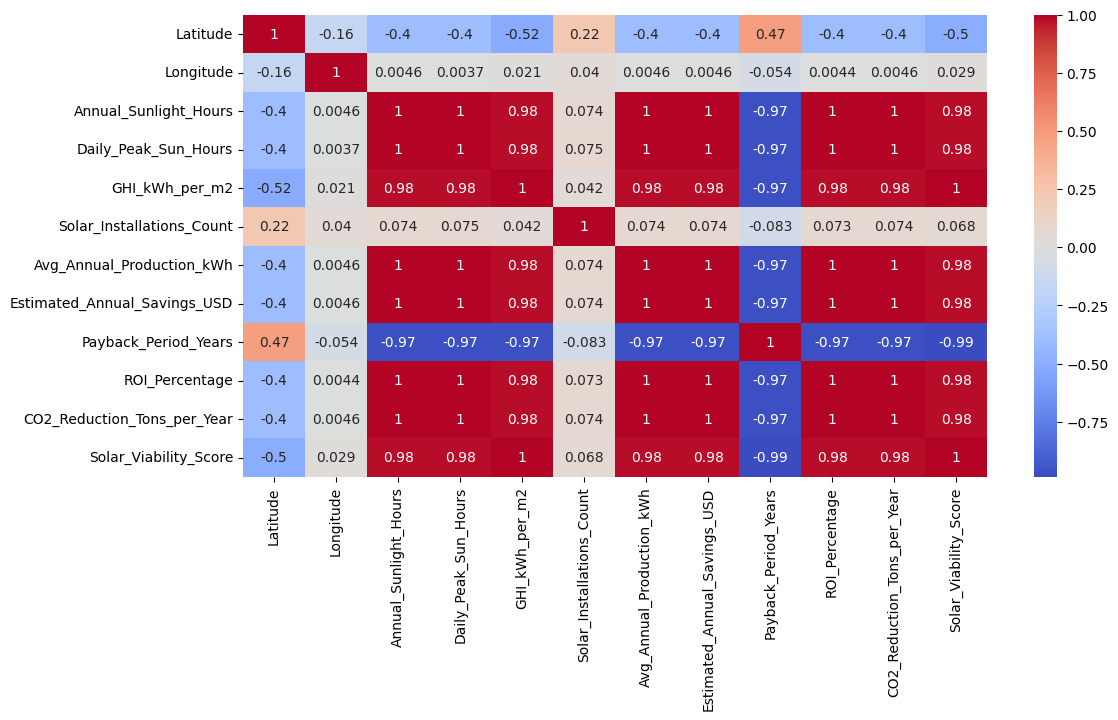

In [37]:
plt.figure(figsize=(12, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')

Almost all features have correlations close to 1. Therefore, if this dataset is used for modeling, it may lead to overfitting. In addition, the high correlation between features and the relatively low data dimensionality further increase the risk of overfitting.

# Principal Component Analysis (PCA)
Principal Component Analysis (PCA)
PCA aims to identify relationships between features in high-dimensional data, allowing each data point to be represented with fewer features while still preserving the essential information.

PCA reduces data dimensionality by combining several correlated features into new features called principal components. This is one of the reasons why PCA is used in the preprocessing step, so the model can better learn the data structure and form more accurate clusters.

In [38]:
from sklearn.preprocessing import StandardScaler

dat_scale = StandardScaler().fit_transform(X)

In [39]:
# Calculating the Covariance Matrix
cov_mat = np.cov(dat_scale.T)

print('Covariance matrix: \n%s' %cov_mat)

Covariance matrix: 
[[ 1.0212766  -0.16367165 -0.41051425 -0.41023271 -0.53048387  0.22931186
  -0.41051425 -0.41051425  0.48204761 -0.40873498 -0.41051425 -0.51149366]
 [-0.16367165  1.0212766   0.00470678  0.00379567  0.02093961  0.04123057
   0.00470678  0.00470678 -0.05489168  0.00449084  0.00470678  0.02915182]
 [-0.41051425  0.00470678  1.0212766   1.02109771  1.00006621  0.07556048
   1.0212766   1.0212766  -0.99181291  1.02107953  1.0212766   1.00388987]
 [-0.41023271  0.00379567  1.02109771  1.0212766   0.9993783   0.07626447
   1.02109771  1.02109771 -0.99135415  1.02103214  1.02109771  1.0033242 ]
 [-0.53048387  0.02093961  1.00006621  0.9993783   1.0212766   0.04285405
   1.00006621  1.00006621 -0.99241133  0.99999655  1.00006621  1.01688557]
 [ 0.22931186  0.04123057  0.07556048  0.07626447  0.04285405  1.0212766
   0.07556048  0.07556048 -0.08496055  0.07447725  0.07556048  0.06935538]
 [-0.41051425  0.00470678  1.0212766   1.02109771  1.00006621  0.07556048
   1.0212766 

In [40]:
# Calculating the Correlation Matrix
cor_mat = np.corrcoef(dat_scale.T)

print('Correlation matrix: \n%s' %cor_mat)

Correlation matrix: 
[[ 1.         -0.16026182 -0.40196187 -0.40168619 -0.51943212  0.22453453
  -0.40196187 -0.40196187  0.47200495 -0.40021966 -0.40196187 -0.50083754]
 [-0.16026182  1.          0.00460872  0.00371659  0.02050336  0.0403716
   0.00460872  0.00460872 -0.0537481   0.00439728  0.00460872  0.02854449]
 [-0.40196187  0.00460872  1.          0.99982484  0.97923149  0.0739863
   1.          1.         -0.97115014  0.99980704  1.          0.9829755 ]
 [-0.40168619  0.00371659  0.99982484  1.          0.97855792  0.07467562
   0.99982484  0.99982484 -0.97070094  0.99976064  0.99982484  0.98242162]
 [-0.51943212  0.02050336  0.97923149  0.97855792  1.          0.04196125
   0.97923149  0.97923149 -0.97173609  0.97916329  0.97923149  0.99570045]
 [ 0.22453453  0.0403716   0.0739863   0.07467562  0.04196125  1.
   0.0739863   0.0739863  -0.08319054  0.07292564  0.0739863   0.06791048]
 [-0.40196187  0.00460872  1.          0.99982484  0.97923149  0.0739863
   1.          1.     

In [41]:
# Calculating Eigenvectors and Eigenvalues from the Covariance Matrix
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

print('Eigenvectors \n%s' %eig_vecs)
print('\nEigenvalues \n%s' %eig_vals)

Eigenvectors 
[[-1.57805050e-01  6.01789338e-01  5.97575828e-02 -7.55887023e-01
  -1.54406528e-01  1.18906048e-01  1.51736796e-03  5.22608460e-03
  -1.16585396e-03 -9.80178660e-16  9.20181478e-15 -3.61211993e-15]
 [ 8.44944549e-03 -3.40431162e-01 -8.74679631e-01 -3.43374101e-01
   2.38979812e-02  2.19234121e-02 -3.44059986e-03  1.12093670e-03
  -3.96636246e-04  6.44155286e-16  1.49137919e-15 -1.07080332e-15]
 [ 3.29716058e-01  5.04189507e-02  1.86375257e-02 -8.22073999e-02
   1.91033804e-01 -9.97028058e-02 -4.25321400e-02  3.57424587e-02
   2.86563721e-01 -1.59183185e-01  5.57286900e-01  4.79420098e-01]
 [ 3.29631041e-01  5.12238015e-02  1.90913582e-02 -8.14638357e-02
   2.01611601e-01 -1.19765411e-01 -6.99243067e-02  6.05330176e-01
  -6.74843420e-01  5.42937645e-13  9.07450058e-13 -6.54088476e-13]
 [ 3.28397369e-01 -3.81478058e-02  1.10277094e-02  5.27215927e-02
  -1.36904497e-01  7.68239844e-01  5.02727155e-01  1.51032267e-01
   5.76029436e-02 -1.16898817e-13  3.79460545e-13 -4.26213

In [42]:
# Calculating Eigenvectors and Eigenvalues from the Correlation Matrix
eig_vals, eig_vecs = np.linalg.eig(cor_mat)

print('Eigenvectors \n%s' %eig_vecs)
print('\nEigenvalues \n%s' %eig_vals)

Eigenvectors 
[[-1.57805050e-01+0.00000000e+00j -6.01789338e-01+0.00000000e+00j
  -5.97575828e-02+0.00000000e+00j -7.55887023e-01+0.00000000e+00j
  -1.54406528e-01+0.00000000e+00j  1.18906048e-01+0.00000000e+00j
  -1.51736796e-03+0.00000000e+00j -5.22608460e-03+0.00000000e+00j
  -1.16585396e-03+0.00000000e+00j  6.48626169e-15-2.19552541e-15j
   6.48626169e-15+2.19552541e-15j  2.14444534e-15+0.00000000e+00j]
 [ 8.44944549e-03+0.00000000e+00j  3.40431162e-01+0.00000000e+00j
   8.74679631e-01+0.00000000e+00j -3.43374101e-01+0.00000000e+00j
   2.38979812e-02+0.00000000e+00j  2.19234121e-02+0.00000000e+00j
   3.44059986e-03+0.00000000e+00j -1.12093670e-03+0.00000000e+00j
  -3.96636246e-04+0.00000000e+00j  1.54105257e-15+9.06622476e-17j
   1.54105257e-15-9.06622476e-17j  9.52481777e-16+0.00000000e+00j]
 [ 3.29716058e-01+0.00000000e+00j -5.04189507e-02+0.00000000e+00j
  -1.86375257e-02+0.00000000e+00j -8.22073999e-02+0.00000000e+00j
   1.91033804e-01+0.00000000e+00j -9.97028058e-02+0.00000000

In [43]:
# Create a list of eigenvalue-eigenvector pairs
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

# Sort eigenvalues and eigenvectors from highest to lowest
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Display eigenvalues in descending order
print('Eigenvalues in descending order:')
for i in eig_pairs:
    print(i[0])

Eigenvalues in descending order:
9.112973337216536
1.198690903719561
1.0345541391510817
0.5842919587090472
0.046847299242025214
0.02143252149557285
0.0007374467365195038
0.00030214882139380055
0.0001702449082685407
2.8361998533701425e-17
2.8361998533701425e-17
3.910468440555214e-18


In [44]:
# Calculate cumulative variance
tot = sum(eig_vals)
var_exp = [(i / tot)*100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


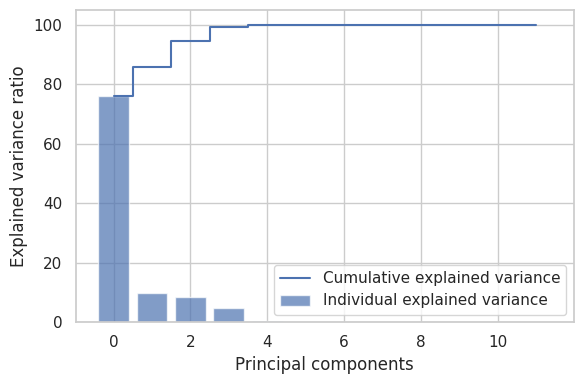

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# set seaborn theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))

plt.bar(
    range(len(var_exp)),
    var_exp,
    alpha=0.7,
    label='Individual explained variance'
)

plt.step(
    range(len(cum_var_exp)),
    cum_var_exp,
    where='mid',
    label='Cumulative explained variance'
)

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


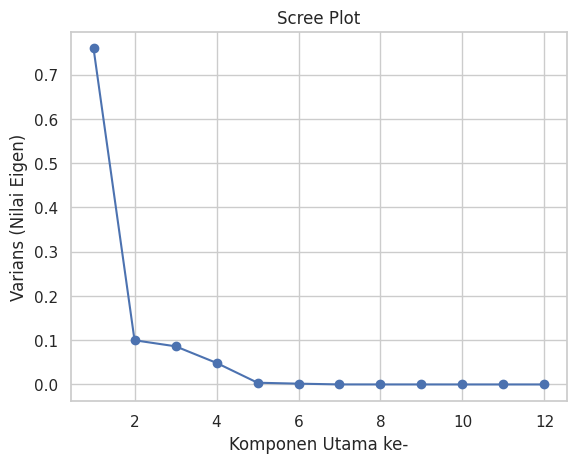

In [46]:
# Perform PCA for dimensionality reduction
feature_number = len(dat_scale[0])
pca = PCA(n_components=feature_number)

# Fit PCA with dataset
pca.fit(dat_scale)

# Get variance information
variance_ratio = pca.explained_variance_ratio_

# Calculate cummulative
cumulative_variance = np.cumsum(variance_ratio)

# Create Scree Plot
plt.plot(range(1, len(variance_ratio) + 1), variance_ratio, marker='o')
plt.xlabel('Komponen Utama ke-')
plt.ylabel('Varians (Nilai Eigen)')
plt.title('Scree Plot')
plt.show()

In [47]:
pca = PCA(n_components=5)
heart_data_reduced = pca.fit_transform(dat_scale)

In [48]:
feature_names = df.drop('Region', axis=1).columns.to_list()
component_names = [f"PC{i+1}" for i in range(pca.n_components_)]

for component, component_name in zip(pca.components_, component_names):
    feature_indices = component.argsort()[::-1]
    retained_features = [feature_names[idx] for idx in feature_indices[:pca.n_components_]]
    print(f"{component_name}: {retained_features}")

PC1: ['GHI_kWh_per_m2', 'Electricity_Price_USD_per_kWh', 'Latitude', 'Avg_Annual_Production_kWh', 'Longitude']
PC2: ['Daily_Peak_Sun_Hours', 'City', 'Longitude', 'Avg_System_Cost_USD', 'Electricity_Price_USD_per_kWh']
PC3: ['Country', 'Daily_Peak_Sun_Hours', 'Estimated_Annual_Savings_USD', 'Annual_Sunlight_Hours', 'Avg_Annual_Production_kWh']
PC4: ['City', 'Country', 'Avg_System_Cost_USD', 'Latitude', 'Electricity_Price_USD_per_kWh']
PC5: ['Solar_Installations_Count', 'Avg_System_Cost_USD', 'Longitude', 'Avg_Annual_Production_kWh', 'GHI_kWh_per_m2']


In [49]:
# Dimensionality reduction dengan PCA (reduce ke 2 dimensi)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(dat_scale)

print(f"Explained variance ratio by PCA: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {sum(pca.explained_variance_ratio_):.2f}")

Explained variance ratio by PCA: [0.75941444 0.09989091 0.08621284 0.048691   0.00390394]
Cumulative explained variance: 1.00


In [50]:
# Determine the Optimal Number of Clusters
inertia = []
sil_scores = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, kmeans.labels_))

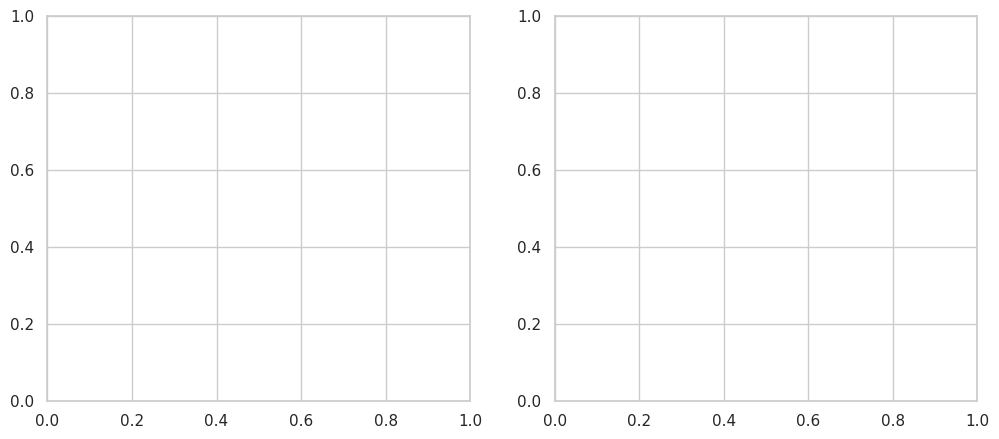

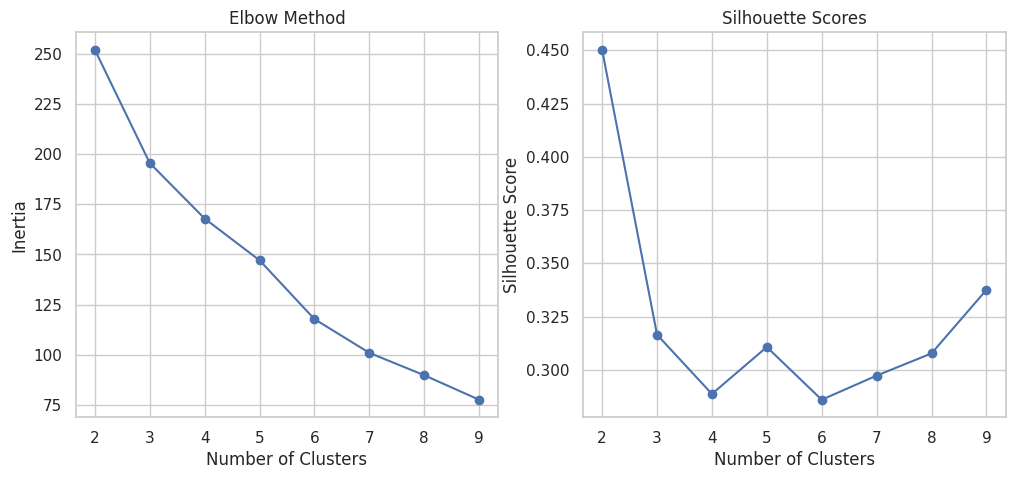

In [51]:
# Plot Elbow dan Silhouette (Visualization)
fig, ax1 = plt.subplots(1, 2, figsize=(12, 5))
fig, ax1 = plt.subplots(1, 2, figsize=(12, 5))

ax1[0].plot(K, inertia, 'bo-')
ax1[0].set_xlabel('Number of Clusters')
ax1[0].set_ylabel('Inertia')
ax1[0].set_title('Elbow Method')

ax1[1].plot(K, sil_scores, 'bo-')
ax1[1].set_xlabel('Number of Clusters')
ax1[1].set_ylabel('Silhouette Score')
ax1[1].set_title('Silhouette Scores')

plt.show()

In [52]:
# Select optimal K based on maximum silhouette score
optimal_k = K[np.argmax(sil_scores)]
print(f"Optimal number of clusters: {optimal_k}")

Optimal number of clusters: 2


In [53]:
# Train final K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_pca)

KMeans(n_clusters=2, random_state=42)

In [54]:
# Add cluster labels to the dataframe
df['Cluster'] = kmeans.labels_

# Display results
print("Cluster Centers (in PCA space):\n", kmeans.cluster_centers_)
print("\nData with Cluster Labels:\n", df[['City', 'Country', 'Solar_Viability_Score', 'Cluster']])

Cluster Centers (in PCA space):
 [[ 2.18577075 -0.14962961  0.00847756 -0.08022715 -0.01027247]
 [-3.06007905  0.20948146 -0.01186858  0.11231801  0.01438145]]

Data with Cluster Labels:
               City         Country  Solar_Viability_Score  Cluster
0         New York   United States                     56        0
1      Los Angeles   United States                     67        0
2            Miami   United States                     63        0
3          Phoenix   United States                     73        0
4          Chicago   United States                     53        1
5           Berlin         Germany                     41        1
6           Munich         Germany                     43        1
7           London  United Kingdom                     37        1
8       Manchester  United Kingdom                     36        1
9            Paris          France                     43        1
10            Lyon          France                     49        1
11      

In [55]:
print("\n--- Data for Cluster 0 ---")
print(df[df['Cluster'] == 0][['City', 'Country', 'Solar_Viability_Score', 'Cluster']])

print("\n--- Data for Cluster 1 ---")
print(df[df['Cluster'] == 1][['City', 'Country', 'Solar_Viability_Score', 'Cluster']])


--- Data for Cluster 0 ---
              City        Country  Solar_Viability_Score  Cluster
0         New York  United States                     56        0
1      Los Angeles  United States                     67        0
2            Miami  United States                     63        0
3          Phoenix  United States                     73        0
11            Rome          Italy                     57        0
13          Madrid          Spain                     62        0
14       Barcelona          Spain                     60        0
17          Sydney      Australia                     61        0
18       Melbourne      Australia                     56        0
19        Brisbane      Australia                     63        0
22         Beijing          China                     58        0
24           Delhi          India                     64        0
25          Mumbai          India                     61        0
26       Bangalore          India               

In [56]:
# Summary per cluster (e.g., average Solar Viability Score)
cluster_summary = df.groupby('Cluster')['Solar_Viability_Score'].mean().sort_values()
print("\nAverage Solar Viability Score per Cluster:\n", cluster_summary)


Average Solar Viability Score per Cluster:
 Cluster
1    44.600000
0    61.571429
Name: Solar_Viability_Score, dtype: float64


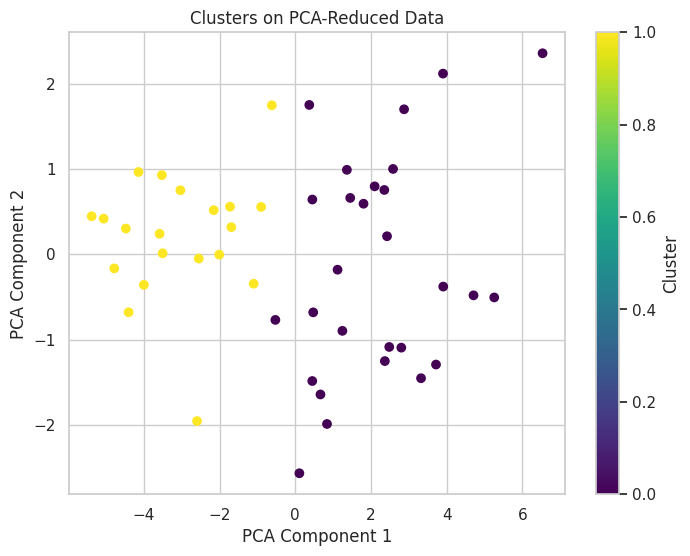

In [57]:
# Cluster visualization in PCA space
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters on PCA-Reduced Data')

plt.colorbar(label='Cluster')
plt.show()

In [58]:
# Key columns for feasibility evaluation
indicators = [
    "Solar_Viability_Score",
    "Payback_Period_Years",
    "ROI_Percentage",
    "Estimated_Annual_Savings_USD",
    "Avg_System_Cost_USD",
    "Avg_Annual_Production_kWh",
    "CO2_Reduction_Tons_per_Year",
    "GHI_kWh_per_m2",
    "Daily_Peak_Sun_Hours",
    "Annual_Sunlight_Hours",
    "Electricity_Price_USD_per_kWh",
    "Solar_Installations_Count"
]

available_indicators = [c for c in indicators if c in df.columns]

In [59]:
# Average summary per cluster
cluster_summary = (
    df.groupby("Cluster")[available_indicators]
      .mean(numeric_only=True)
      .sort_values(by="Solar_Viability_Score", ascending=False)
)

cluster_summary

,Solar_Viability_Score,Payback_Period_Years,ROI_Percentage,Estimated_Annual_Savings_USD,Avg_System_Cost_USD,Avg_Annual_Production_kWh,CO2_Reduction_Tons_per_Year,GHI_kWh_per_m2,Daily_Peak_Sun_Hours,Annual_Sunlight_Hours,Electricity_Price_USD_per_kWh,Solar_Installations_Count
Cluster,,,,,,,,,,,,
0,61.571429,8.003571,12.707143,1902.053571,15000.0,12680.357143,5.072143,5.253571,7.710714,2817.857143,0.15,8.431163
1,44.600000,12.270000,8.280000,1243.687500,15000.0,8291.250000,3.316500,3.520000,5.050000,1842.500000,0.15,8.480003


In [60]:
# Get cluster ranking based on highest Solar_Viability_Score
ranking_cluster = cluster_summary.sort_values("Solar_Viability_Score", ascending=False).index.tolist()

In [61]:
# Best cluster (most feasible)
best_cluster = ranking_cluster[0]
print("Most feasible cluster (highest score):", best_cluster)

Most feasible cluster (highest score): 0


In [62]:
# Create category labels (Highly Feasible / Feasible / Less Feasible)
label_map = {}
if len(ranking_cluster) >= 3:
    label_map[ranking_cluster[0]] = "Highly Feasible"
    label_map[ranking_cluster[1]] = "Feasible"
    for c in ranking_cluster[2:]:
        label_map[c] = "Less Feasible"
else:
    for i, c in enumerate(ranking_cluster):
        label_map[c] = f"Group-{i+1}"

df["Feasibility_Category"] = df["Cluster"].map(label_map)

df[["Cluster", "Feasibility_Category"]].drop_duplicates().sort_values("Cluster")

,Cluster,Feasibility_Category
0,0,Group-1
4,1,Group-2


In [63]:
# Top 10 most feasible locations
# ============================================================

location_cols = [c for c in ["City", "Country", "Region"] if c in df.columns]
display_cols = location_cols + [
    "Solar_Viability_Score",
    "Payback_Period_Years",
    "ROI_Percentage",
    "Estimated_Annual_Savings_USD",
    "GHI_kWh_per_m2",
    "Daily_Peak_Sun_Hours",
    "Feasibility_Category"
]
display_cols = [c for c in display_cols if c in df.columns]

top10 = df.sort_values("Solar_Viability_Score", ascending=False).head(10)
top10[display_cols]

,City,Country,Region,Solar_Viability_Score,Payback_Period_Years,ROI_Percentage,Estimated_Annual_Savings_USD,GHI_kWh_per_m2,Daily_Peak_Sun_Hours,Feasibility_Category
3,Phoenix,United States,North America,73,5.8,17.2,2565.0,6.5,10.4,Group-1
38,Dubai,UAE,Asia,70,6.3,15.9,2362.5,6.2,9.6,Group-1
46,Cairo,Egypt,Africa,68,6.5,15.4,2295.0,6.0,9.3,Group-1
1,Los Angeles,United States,North America,67,6.9,14.5,2160.0,5.8,8.8,Group-1
47,Tel Aviv,Israel,Middle East,67,6.9,14.5,2160.0,5.9,8.8,Group-1
29,Johannesburg,South Africa,Africa,66,7.2,13.9,2092.5,5.7,8.5,Group-1
30,Cape Town,South Africa,Africa,65,7.4,13.5,2025.0,5.6,8.2,Group-1
24,Delhi,India,Asia,64,7.7,13.0,1957.5,5.5,7.9,Group-1
19,Brisbane,Australia,Oceania,63,7.7,13.0,1957.5,5.4,7.9,Group-1
37,Athens,Greece,Europe,63,7.7,13.0,1957.5,5.4,7.9,Group-1


In [64]:
# Top 10 fastest payback (lowest years)
# ============================================================

if "Payback_Period_Years" in df.columns:
    top10_payback = df.sort_values("Payback_Period_Years", ascending=True).head(10)
    top10_payback[display_cols]
else:
    print("Column Payback_Period_Years not found.")

In [65]:
print("=== SUMMARY INSIGHTS OF SOLAR ENERGY FEASIBILITY EVALUATION ===")

# Number of clusters
print(f"Number of clusters: {df['Cluster'].nunique()}")

# Distribution of feasibility categories
print("\nDistribution of feasibility categories:")
if "Feasibility_Category" in df.columns:
    print(df["Feasibility_Category"].value_counts(dropna=False))
else:
    print("Column 'Feasibility_Category' not found. Run mapping first:")
    print("df['Feasibility_Category'] = df['Cluster'].map(label_map)")

# Solar Viability Score
if "Feasibility_Category" in df.columns and "Solar_Viability_Score" in df.columns:
    print("\nAverage Solar Viability Score per category:")
    print(
        df.groupby("Feasibility_Category")["Solar_Viability_Score"]
        .mean()
        .sort_values(ascending=False)
    )

# ROI
if "Feasibility_Category" in df.columns and "ROI_Percentage" in df.columns:
    print("\nAverage ROI (%) per category:")
    print(
        df.groupby("Feasibility_Category")["ROI_Percentage"]
        .mean()
        .sort_values(ascending=False)
    )

# Payback Period
if "Feasibility_Category" in df.columns and "Payback_Period_Years" in df.columns:
    print("\nAverage Payback Period (years) per category (lower is better):")
    print(
        df.groupby("Feasibility_Category")["Payback_Period_Years"]
        .mean()
        .sort_values()
    )

=== SUMMARY INSIGHTS OF SOLAR ENERGY FEASIBILITY EVALUATION ===
Number of clusters: 2

Distribution of feasibility categories:
Feasibility_Category
Group-1    28
Group-2    20
Name: count, dtype: int64

Average Solar Viability Score per category:
Feasibility_Category
Group-1    61.571429
Group-2    44.600000
Name: Solar_Viability_Score, dtype: float64

Average ROI (%) per category:
Feasibility_Category
Group-1    12.707143
Group-2     8.280000
Name: ROI_Percentage, dtype: float64

Average Payback Period (years) per category (lower is better):
Feasibility_Category
Group-1     8.003571
Group-2    12.270000
Name: Payback_Period_Years, dtype: float64


## Comparison of Clustering Algorithms

In [66]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
X_pca

array([[ 3.71979304e-01,  1.74943704e+00, -4.28399611e-01,
        -6.06454412e-01, -2.15399642e-01],
       [ 3.90499543e+00,  2.11639654e+00, -1.03227656e+00,
        -4.90840947e-01,  4.45293658e-02],
       [ 2.87676808e+00,  1.69852286e+00, -5.49354544e-01,
        -6.62016768e-01,  4.99978923e-02],
       [ 6.53614393e+00,  2.35493471e+00, -1.06597062e+00,
        -3.60985863e-02,  6.06463114e-01],
       [-6.17821906e-01,  1.74560752e+00, -5.56482523e-01,
        -7.72787391e-01, -2.25241884e-01],
       [-4.13970037e+00,  9.63862045e-01,  4.60526689e-01,
        -2.92446991e-01,  1.77896401e-01],
       [-3.52251925e+00,  9.27121534e-01,  4.39160489e-01,
        -3.46417465e-01,  5.98593531e-02],
       [-5.06094875e+00,  4.17134702e-01, -3.37875049e-02,
        -8.14933701e-02,  4.44703511e-01],
       [-5.37777354e+00,  4.45037415e-01, -5.84891620e-02,
        -7.20141486e-02,  5.37412490e-01],
       [-3.58308881e+00,  2.39465145e-01, -1.67049326e-01,
         1.76974229e-01

In [68]:
print(X_pca.shape)

(48, 5)


In [69]:
# K-Means Evaluation

from sklearn.metrics import silhouette_score

kmeans_labels = df['Cluster']

kmeans_silhouette = silhouette_score(X_pca, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("Number of K-Means Clusters:", len(set(kmeans_labels)))

K-Means Silhouette Score: 0.45024633166995276
Number of K-Means Clusters: 2


In [70]:
# DBSCAN

from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN Cluster Labels:", np.unique(dbscan_labels))

DBSCAN Cluster Labels: [-1  0  1]


In [71]:
# Count clusters and noise in DBSCAN

dbscan_cluster_count = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_noise_count = list(dbscan_labels).count(-1)

print("Number of DBSCAN Clusters:", dbscan_cluster_count)
print("Number of Noise/Outliers:", dbscan_noise_count)

Number of DBSCAN Clusters: 2
Number of Noise/Outliers: 15


In [72]:
# DBSCAN Evaluation

if dbscan_cluster_count > 1:
    dbscan_silhouette = silhouette_score(X_pca, dbscan_labels)
else:
    dbscan_silhouette = np.nan
    print("DBSCAN Silhouette Score cannot be calculated because the number of clusters is less than 2.")

print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.2519166847271701


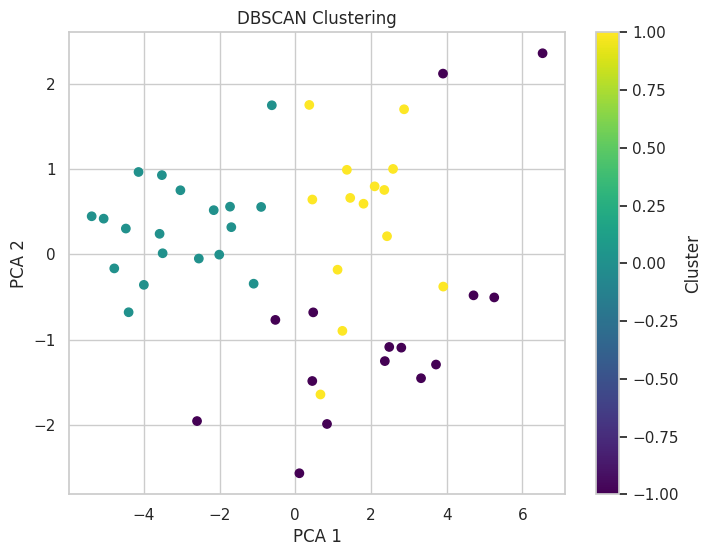

In [73]:
# DBSCAN Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis')

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar(label="Cluster")
plt.show()

In [74]:
# Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2)

hc_labels = hc.fit_predict(X_pca)

df['Hierarchical_Cluster'] = hc_labels

print("Hierarchical Cluster Labels:", np.unique(hc_labels))

Hierarchical Cluster Labels: [0 1]


In [75]:
# Hierarchical Evaluation

hierarchical_silhouette = silhouette_score(X_pca, hc_labels)

print("Hierarchical Silhouette Score:", hierarchical_silhouette)
print("Number of Hierarchical Clusters:", len(set(hc_labels)))

Hierarchical Silhouette Score: 0.450123970235859
Number of Hierarchical Clusters: 2


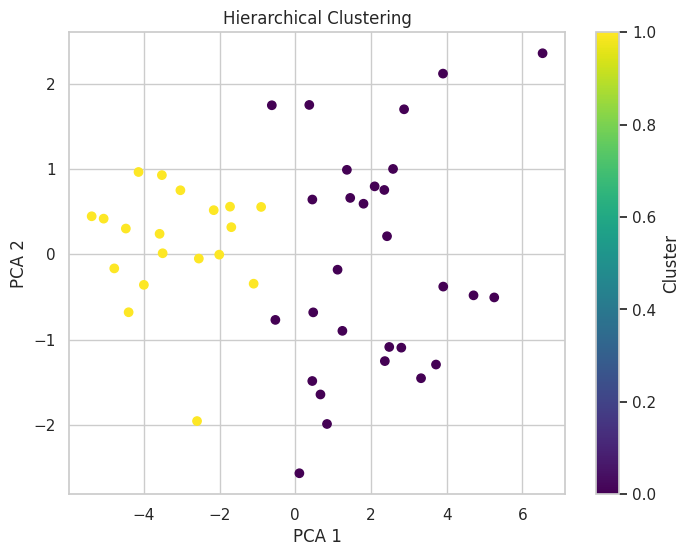

In [76]:
# Hierarchical Visualization

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='viridis')

plt.title("Hierarchical Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar(label="Cluster")
plt.show()

In [77]:
# Comparison Table

comparison_df = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "Hierarchical"],
    "Number of Clusters": [
        len(set(kmeans_labels)),
        dbscan_cluster_count,
        len(set(hc_labels))
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette,
        hierarchical_silhouette
    ],
    "Notes": [
        "Clusters determined based on Elbow/Silhouette evaluation",
        "Can detect noise/outliers",
        "Groups data hierarchically"
    ]
})

comparison_df

,Algorithm,Number of Clusters,Silhouette Score,Notes
0,K-Means,2,0.450246,Clusters determined based on Elbow/Silhouette ...
1,DBSCAN,2,0.251917,Can detect noise/outliers
2,Hierarchical,2,0.450124,Groups data hierarchically


In [78]:
# Best Algorithm

best_algorithm = comparison_df.loc[
    comparison_df["Silhouette Score"].idxmax(),
    "Algorithm"
]

print("The algorithm with the best Silhouette Score is:", best_algorithm)

The algorithm with the best Silhouette Score is: K-Means


In [79]:
import pickle

In [80]:
# Save sacaler

with open("scaler_solar.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [81]:
# Save PCA

with open("pca_solar.pkl", "wb") as f:
    pickle.dump(pca, f)

In [82]:
# Save K-Means

with open("kmeans_solar.pkl", "wb") as f:
    pickle.dump(kmeans, f)

In [83]:
# Save DBSCAN

with open("dbscan_solar.pkl", "wb") as f:
    pickle.dump(dbscan, f)

In [84]:
# Save Hierarchical

with open("hierarchical_solar.pkl", "wb") as f:
    pickle.dump(hc, f)

In [85]:
# Save Feature Names

feature_names_solar = X.columns.tolist()

with open("feature_names_solar.pkl", "wb") as f:
    pickle.dump(feature_names_solar, f)

In [86]:
# Save comparison results

comparison_df.to_csv("clustering_algorithm_comparison.csv", index=False)